In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving sensor_kualitas_elektronik.csv to sensor_kualitas_elektronik.csv


In [5]:
df=pd.read_csv('sensor_kualitas_elektronik.csv')
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Unit                1800 non-null   object 
 1   Tegangan_Output_Volt   1692 non-null   float64
 2   Arus_Output_Ampere     1674 non-null   float64
 3   Suhu_Komponen_Celcius  1800 non-null   float64
 4   Waktu_Uji_Detik        1800 non-null   float64
 5   Line_Perakitan         1800 non-null   object 
 6   Status_Akhir           1800 non-null   object 
dtypes: float64(4), object(3)
memory usage: 98.6+ KB


,Tegangan_Output_Volt,Arus_Output_Ampere,Suhu_Komponen_Celcius,Waktu_Uji_Detik
count,1692.000000,1674.000000,1800.000000,1800.000000
mean,11.864223,2.055350,45.927667,17.878222
std,0.488638,0.274643,6.688752,3.004420
min,9.750000,1.191000,22.100000,8.600000
25%,11.636000,1.873000,41.300000,15.800000
50%,11.923000,2.036000,45.500000,17.900000
75%,12.193000,2.228000,50.000000,19.900000
max,13.753000,3.049000,76.000000,28.900000


In [7]:
df.describe(include='object')


,ID_Unit,Line_Perakitan,Status_Akhir
count,1800,1800,1800
unique,1800,3,2
top,U01800,L1,Lolos
freq,1,610,1565


In [8]:
df['Status_Akhir'].value_counts()

,count
Status_Akhir,
Lolos,1565
Gagal,235


In [9]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percent
Tegangan_Output_Volt,108,6.0
Arus_Output_Ampere,126,7.0


In [10]:

median_tegangan = df['Tegangan_Output_Volt'].median()
df['Tegangan_Output_Volt'] = df['Tegangan_Output_Volt'].fillna(median_tegangan)

In [11]:

median_arus = df['Arus_Output_Ampere'].median()
df['Arus_Output_Ampere'] = df['Arus_Output_Ampere'].fillna(median_arus)

In [12]:
df.isnull().sum()

,0
ID_Unit,0
Tegangan_Output_Volt,0
Arus_Output_Ampere,0
Suhu_Komponen_Celcius,0
Waktu_Uji_Detik,0
Line_Perakitan,0
Status_Akhir,0


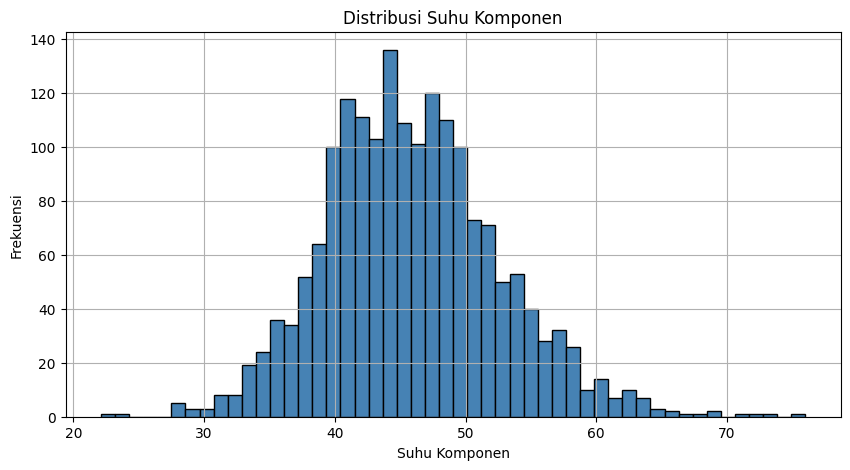

In [13]:
plt.figure(figsize=(10, 5))
df['Suhu_Komponen_Celcius'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribusi Suhu Komponen')
plt.xlabel('Suhu Komponen')
plt.ylabel('Frekuensi')
plt.show()

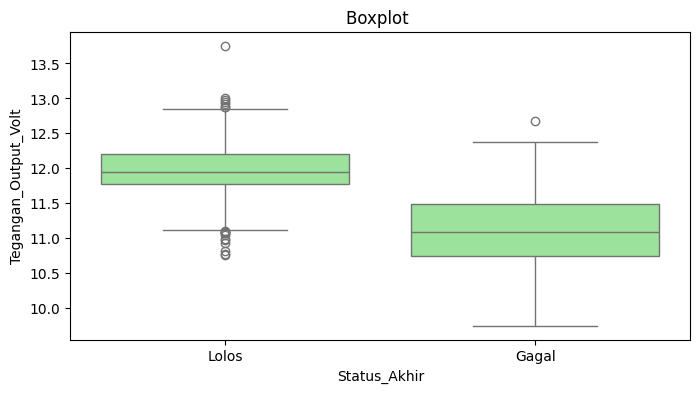

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df,x='Status_Akhir',y='Tegangan_Output_Volt', color='lightgreen')
plt.title('Boxplot ')
plt.show()

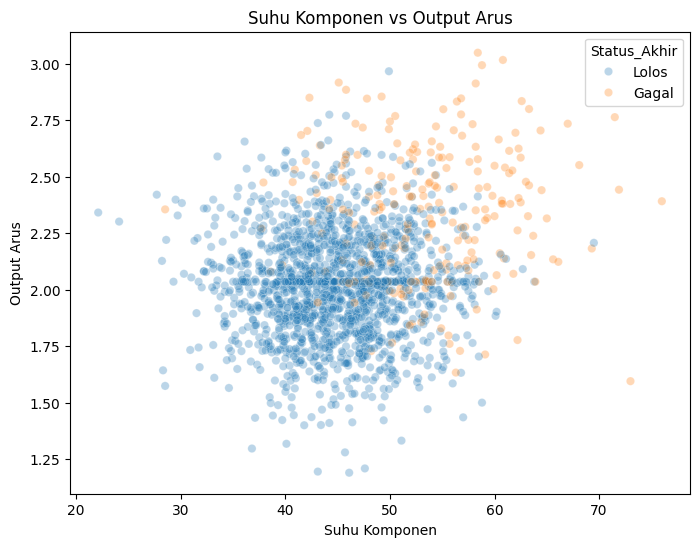

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Suhu_Komponen_Celcius', y='Arus_Output_Ampere', hue='Status_Akhir', alpha=0.3)
plt.xlabel('Suhu Komponen')
plt.ylabel('Output Arus')
plt.title('Suhu Komponen vs Output Arus')
plt.show()